Total People: 350
Healthy: 175
Tumor: 105
Pneumonia: 70
HPC Feature Extraction Time: 11.8494 seconds
Disease Classification Accuracy: 100.0 %


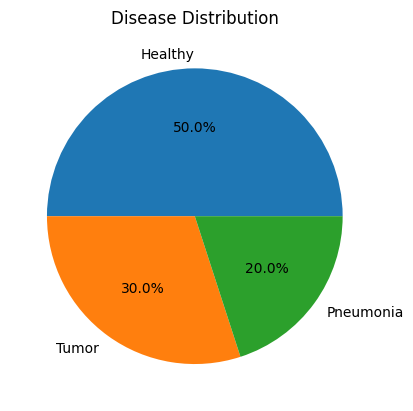

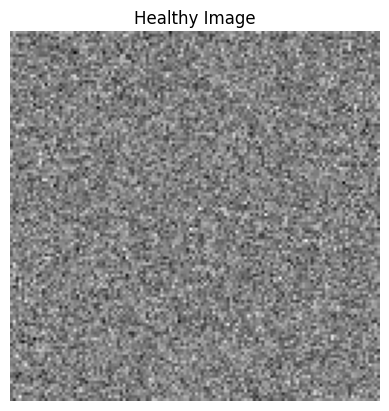

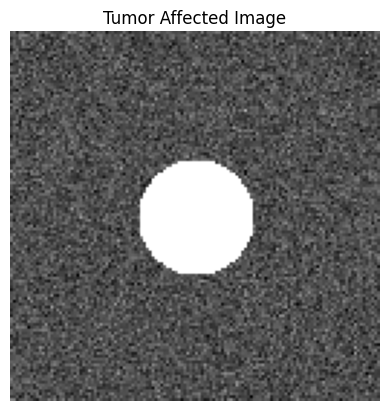

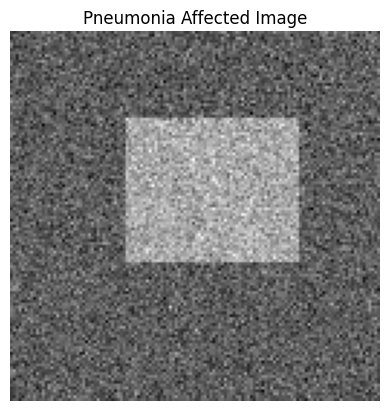

Sequential Time: 0.8364 seconds
Parallel (HPC) Time: 0.176 seconds
HPC Speedup: 4.75 x faster


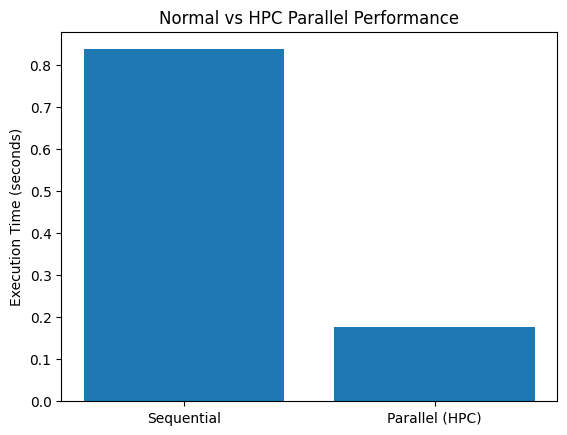

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# Generate Synthetic Medical Images (Uneven Data)
# --------------------------------------------------
def generate_images(n_samples=300):
    images = []
    labels = []

    for i in range(n_samples):
        img = np.random.normal(100, 20, (128,128))

        # 50% Healthy
        if i < int(0.5 * n_samples):
            labels.append(0)

        # 30% Tumor
        elif i < int(0.8 * n_samples):
            rr, cc = np.ogrid[:128, :128]
            mask = (rr-64)**2 + (cc-64)**2 < 20**2
            img[mask] = 255
            labels.append(1)

        # 20% Pneumonia
        else:
            img[30:80, 40:100] += 60
            labels.append(2)

        images.append(img)

    return np.array(images), np.array(labels)


# --------------------------------------------------
# HPC Feature Extraction using Numba
# --------------------------------------------------
@njit(parallel=True)
def extract_features(images):
    n = images.shape[0]
    features = np.zeros((n, 3))

    for i in prange(n):
        img = images[i]
        features[i,0] = np.mean(img)
        features[i,1] = np.std(img)
        features[i,2] = np.max(img)

    return features


# --------------------------------------------------
#  Generate Dataset
# --------------------------------------------------
images, labels = generate_images(350)

disease_names = ["Healthy", "Tumor", "Pneumonia"]

total_people = len(labels)
healthy_count = np.sum(labels == 0)
tumor_count = np.sum(labels == 1)
pneumonia_count = np.sum(labels == 2)

print("Total People:", total_people)
print("Healthy:", healthy_count)
print("Tumor:", tumor_count)
print("Pneumonia:", pneumonia_count)


# --------------------------------------------------
# HPC Timing
# --------------------------------------------------
start = time.time()
features = extract_features(images)
end = time.time()

print("HPC Feature Extraction Time:", round(end-start,4), "seconds")


# --------------------------------------------------
#  Train Classification Model
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Disease Classification Accuracy:", round(accuracy*100,2), "%")


# --------------------------------------------------
# Disease Distribution PIE CHART
# --------------------------------------------------
plt.figure()
plt.pie(
    [healthy_count, tumor_count, pneumonia_count],
    labels=disease_names,
    autopct='%1.1f%%'
)
plt.title("Disease Distribution")
plt.show()


# --------------------------------------------------
# Display Sample Images
# --------------------------------------------------
healthy_index = np.where(labels == 0)[0][0]
tumor_index = np.where(labels == 1)[0][0]
pneumonia_index = np.where(labels == 2)[0][0]

# Healthy Image
plt.figure()
plt.imshow(images[healthy_index], cmap='gray')
plt.title("Healthy Image")
plt.axis('off')
plt.show()

# Tumor Image
plt.figure()
plt.imshow(images[tumor_index], cmap='gray')
plt.title("Tumor Affected Image")
plt.axis('off')
plt.show()

# Pneumonia Image
plt.figure()
plt.imshow(images[pneumonia_index], cmap='gray')
plt.title("Pneumonia Affected Image")
plt.axis('off')
plt.show()

import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
import math

# --------------------------------------------------
# Generate Large Dataset
# --------------------------------------------------
def generate_images(n_samples=2000):
    images = []
    for i in range(n_samples):
        img = np.random.normal(100, 20, (128,128))
        images.append(img)
    return np.array(images)


# --------------------------------------------------
# Sequential Version (Heavy Computation)
# --------------------------------------------------
def extract_features_sequential(images):
    n = images.shape[0]
    features = np.zeros((n,3))

    for i in range(n):
        img = images[i]

        temp = 0
        for k in range(2000):      # heavy load
            temp += math.sqrt(k)

        features[i,0] = np.mean(img)
        features[i,1] = np.std(img)
        features[i,2] = np.max(img)

    return features


# --------------------------------------------------
# Parallel HPC Version
# --------------------------------------------------
@njit(parallel=True)
def extract_features_parallel(images):
    n = images.shape[0]
    features = np.zeros((n,3))

    for i in prange(n):
        img = images[i]

        temp = 0
        for k in range(2000):   # same heavy load
            temp += np.sqrt(k)

        features[i,0] = np.mean(img)
        features[i,1] = np.std(img)
        features[i,2] = np.max(img)

    return features


# --------------------------------------------------
# Generate Data
# --------------------------------------------------
images = generate_images(3000)

# Warm-up (important for numba)
extract_features_parallel(images[:10])

# --------------------------------------------------
# Sequential Timing
# --------------------------------------------------
start = time.time()
extract_features_sequential(images)
seq_time = time.time() - start

print("Sequential Time:", round(seq_time,4), "seconds")

# --------------------------------------------------
# Parallel Timing
# --------------------------------------------------
start = time.time()
extract_features_parallel(images)
par_time = time.time() - start

print("Parallel (HPC) Time:", round(par_time,4), "seconds")

# --------------------------------------------------
# Speedup
# --------------------------------------------------
speedup = seq_time / par_time
print("HPC Speedup:", round(speedup,2), "x faster")

# --------------------------------------------------
#  Performance Graph
# --------------------------------------------------
plt.figure()
plt.bar(["Sequential", "Parallel (HPC)"], [seq_time, par_time])
plt.title("Normal vs HPC Parallel Performance")
plt.ylabel("Execution Time (seconds)")
plt.show()
